# Exploratory Data Analysis: SME Financial Health (FHI) Classification

In [3]:
# Setup & load data (cleaned via pipeline)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.preprocessing import PreprocessConfig, preprocess_train_test

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", None)

TRAIN_PATH = "D:\\dataorg-financial-health-prediction-challenge20251204-19827-m2tn1n\\Train.csv"
TEST_PATH = "D:\\dataorg-financial-health-prediction-challenge20251204-19827-m2tn1n\\Test.csv"

train_raw = pd.read_csv(TRAIN_PATH)
test_raw = pd.read_csv(TEST_PATH)

cfg = PreprocessConfig(id_col="ID", target_col="Target")

train, test = preprocess_train_test(train_raw, test_raw, cfg, for_model="catboost")

print("train:", train.shape, "| test:", test.shape)
train.head()

train: (9618, 47) | test: (2405, 46)


,ID,country,owner_age,attitude_stable_business_environment,attitude_worried_shutdown,compliance_income_tax,perception_insurance_doesnt_cover_losses,perception_cannot_afford_insurance,personal_income,business_expenses,business_turnover,business_age_years,motor_vehicle_insurance,has_mobile_money,current_problem_cash_flow,has_cellphone,owner_sex,offers_credit_to_customers,attitude_satisfied_with_achievement,has_credit_card,keeps_financial_records,perception_insurance_companies_dont_insure_businesses_like_yours,perception_insurance_important,has_insurance,covid_essential_service,attitude_more_successful_next_year,problem_sourcing_money,marketing_word_of_mouth,has_loan_account,has_internet_banking,has_debit_card,future_risk_theft_stock,business_age_months,medical_insurance,funeral_insurance,motivation_make_more_money,uses_friends_family_savings,uses_informal_lender,Target,personal_income_missing,business_expenses_missing,business_turnover_missing,log_personal_income,log_business_expenses,log_business_turnover,business_age_total_months,business_age_months_ge_12
0,ID_3CFL0U,eswatini,63.0,yes,no,no,no,yes,3000.0,6000.0,7000.0,14.0,never had,have now,yes,yes,male,"yes, sometimes",no,never had,"yes, always",yes,yes,no,yes,yes,yes,yes,never had,never had,never had,NaN,6.0,never had,used to have but don't have now,NaN,never had,never had,Low,0,0,0,8.006701,8.699681,8.853808,174.0,0
1,ID_XWI7G3,zimbabwe,39.0,no,yes,yes,no,yes,NaN,NaN,NaN,15.0,have now,have now,NaN,yes,male,"yes, sometimes",yes,never had,"yes, always",no,yes,yes,yes,NaN,NaN,NaN,NaN,NaN,NaN,no,3.0,never had,never had,NaN,NaN,NaN,Medium,1,1,1,NaN,NaN,NaN,183.0,0
2,ID_TY93LV,malawi,34.0,don't know,no,no,don't know,yes,30000.0,6000.0,13000.0,5.0,NaN,never had,yes,yes,male,"yes, sometimes",yes,never had,no,don't know,yes,no,NaN,yes,yes,no,never had,never had,never had,yes,NaN,NaN,NaN,yes,NaN,NaN,Low,0,0,0,10.308986,8.699681,9.472782,60.0,0
3,ID_9OP2C8,malawi,28.0,yes,no,no,no,no,180000.0,60000.0,30000.0,1.0,NaN,have now,no,yes,female,"yes, sometimes",no,never had,no,no,yes,no,NaN,yes,no,no,never had,never had,never had,no,NaN,NaN,NaN,yes,never had,have now,Low,0,0,0,12.100718,11.002117,10.308986,12.0,0
4,ID_13REYS,zimbabwe,43.0,yes,no,no,yes,yes,50.0,2400.0,1800.0,3.0,never had,NaN,NaN,no,female,"yes, sometimes",yes,never had,no,yes,yes,no,no,NaN,NaN,NaN,NaN,NaN,NaN,no,0.0,never had,never had,yes,NaN,NaN,Low,0,0,0,3.931826,7.783641,7.496097,36.0,0


In [4]:
# Basic EDA overview & sanity checks

TARGET = cfg.target_col
ID = cfg.id_col

print("Target unique:", train[TARGET].unique())
print("Country unique:", train["country"].unique() if "country" in train.columns else "country not found")
print("Owner sex unique:", train["owner_sex"].unique() if "owner_sex" in train.columns else "owner_sex not found")

# Missingness summary (top 15)
missing_pct = train.isna().mean().sort_values(ascending=False) * 100
missing_pct.head(20).to_frame("missing_pct")

Target unique: <StringArray>
['Low', 'Medium', 'High']
Length: 3, dtype: str
Country unique: <StringArray>
['eswatini', 'zimbabwe', 'malawi', 'lesotho']
Length: 4, dtype: str
Owner sex unique: <StringArray>
['male', 'female', nan]
Length: 3, dtype: str


,missing_pct
uses_informal_lender,46.672905
uses_friends_family_savings,46.662508
motivation_make_more_money,44.614265
funeral_insurance,43.543356
medical_insurance,43.543356
business_age_months,42.742774
future_risk_theft_stock,42.628405
has_debit_card,41.619879
has_internet_banking,41.619879
has_loan_account,41.578291


## Target distribution (Overall + by country + by sex)

,count,pct
Target,,
Low,6280,65.29
Medium,2868,29.82
High,470,4.89


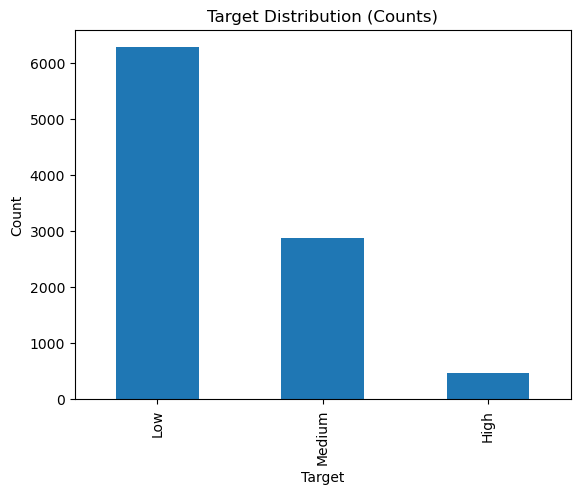

In [5]:
# Target class proportions (table + bar chart)

target_counts = train[TARGET].value_counts()
target_pct = (train[TARGET].value_counts(normalize=True) * 100).round(2)

target_table = pd.DataFrame({
    "count": target_counts,
    "pct": target_pct
})
display(target_table)

plt.figure()
target_counts.plot(kind = "bar")
plt.title("Target Distribution (Counts)")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()


What this tells us;

*- The dataset is imbalanced.*
*- Low dominates, macro-F1 will punish models that ignore Medium/High.*

Target,High,Low,Medium
country,,,
eswatini,11.48,51.42,37.10
lesotho,0.31,60.39,39.30
malawi,4.02,81.24,14.74
zimbabwe,2.34,68.57,29.10


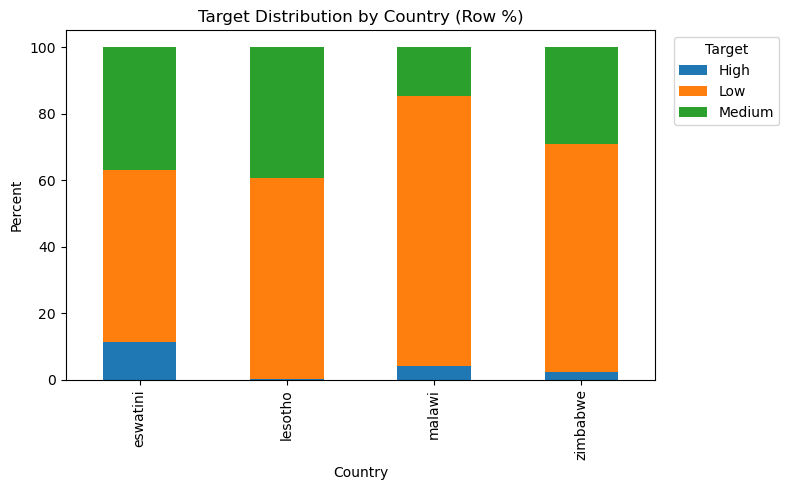

In [6]:
# Target distribution by country (stacked % bar)

if "country" in train.columns:
    ct = (
        pd.crosstab(train["country"], train[TARGET], normalize="index")
        .mul(100)
        .round(2)
    )

    display(ct)

    ax = ct.plot(kind="bar", stacked=True, figsize=(8, 5))
    ax.set_title("Target Distribution by Country (Row %)")
    ax.set_xlabel("Country")
    ax.set_ylabel("Percent")
    ax.legend(title="Target", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

Target,High,Low,Medium
owner_sex,,,
female,5.00,66.70,28.31
male,7.39,66.33,26.28


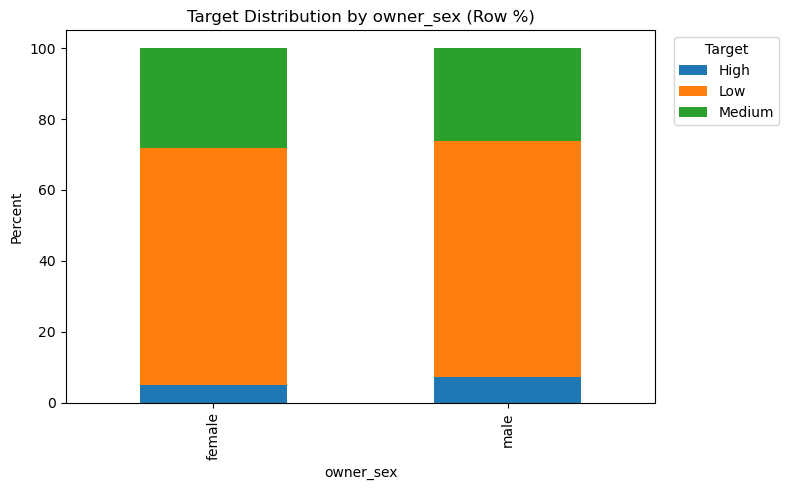

In [7]:
# Target distribution by owner_sex (stacked % bar)

if "owner_sex" in train.columns:
    ct = (
        pd.crosstab(train["owner_sex"], train[TARGET], normalize="index")
        .mul(100)
        .round(2)
    )

    display(ct)

    ax = ct.plot(kind="bar", stacked=True, figsize=(8, 5))
    ax.set_title("Target Distribution by owner_sex (Row %)")
    ax.set_xlabel("owner_sex")
    ax.set_ylabel("Percent")
    ax.legend(title="Target", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

## Univariate relationships (each feature vs Target)

*Done systematically with helper plotting functions.*

In [8]:
# Helper functions (categorical plot + numeric plot)

from pandas.api.types import is_numeric_dtype

def plot_categorical_vs_target(df, col, target=TARGET, top_n=15):
    """
    Stacked bar chart (row %) of Target by categories in col.
    If too many categories, keep top_n and group the rest as 'Other'.
    """
    s = df[col].fillna("missing").astype(str)

    # Reduce high-cardinality for readable plots
    vc = s.value_counts()
    if len(vc) > top_n:
        top_cats = vc.index[:top_n]
        s = s.where(s.isin(top_cats), other="Other")

    tab = pd.crosstab(s, df[target], normalize="index") * 100
    tab = tab.sort_index()

    display(tab.round(2))

    plt.figure()
    tab.plot(kind="bar", stacked=True)
    plt.title(f"{col} vs Target (Row %)")
    plt.xlabel(col)
    plt.ylabel("Percent")
    plt.legend(title=target, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


def plot_numeric_vs_target(df, col, target=TARGET, use_log=False):
    """
    Boxplot-style using matplotlib (simple approach).
    """
    data = df[[col, target]].copy()
    data = data.dropna(subset=[col, target])

    # Optional log transformation for visualization
    if use_log:
        data[col] = np.log1p(data[col].clip(lower=0))

    groups = []
    labels = []
    for cls in sorted(data[target].unique()):
        groups.append(data.loc[data[target] == cls, col].values)
        labels.append(cls)

    plt.figure()
    plt.boxplot(groups, labels=labels, showfliers=False)
    plt.title(f"{col} vs Target ({'log1p' if use_log else 'raw'})")
    plt.xlabel("Target")
    plt.ylabel(col)
    plt.show()

    # Summary table
    summary = data.groupby(target)[col].describe(percentiles=[0.1, 0.5, 0.9]).round(3)
    display(summary)

Target,High,Low,Medium
has_loan_account,,,
don't know,4.35,73.91,21.74
have now,41.51,22.02,36.47
missing,1.68,62.99,35.33
never had,4.40,70.87,24.73
used to have but don't have now,3.49,69.50,27.01


<Figure size 640x480 with 0 Axes>

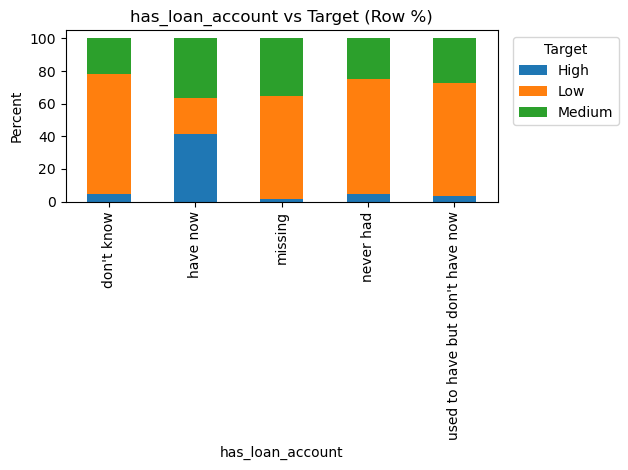

Target,High,Low,Medium
has_debit_card,,,
don't know,9.09,72.73,18.18
have now,16.41,53.55,30.04
missing,1.67,62.98,35.35
never had,3.88,72.18,23.94
used to have but don't have now,5.30,63.58,31.13


<Figure size 640x480 with 0 Axes>

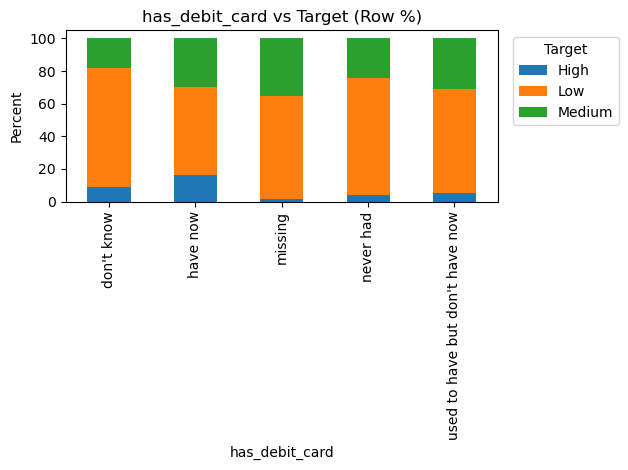

Target,High,Low,Medium
has_credit_card,,,
don't know,5.66,67.92,26.42
have now,56.23,3.56,40.21
missing,0.31,60.45,39.24
never had,4.10,69.22,26.68
used to have but don't have now,6.59,45.05,48.35


<Figure size 640x480 with 0 Axes>

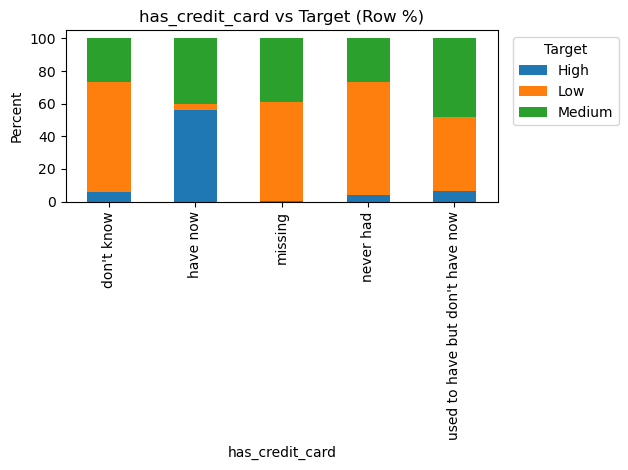

Target,High,Low,Medium
has_internet_banking,,,
don't know,0.00,85.71,14.29
have now,23.64,42.73,33.64
missing,1.67,62.98,35.35
never had,5.67,69.00,25.33
used to have but don't have now,1.81,76.74,21.45


<Figure size 640x480 with 0 Axes>

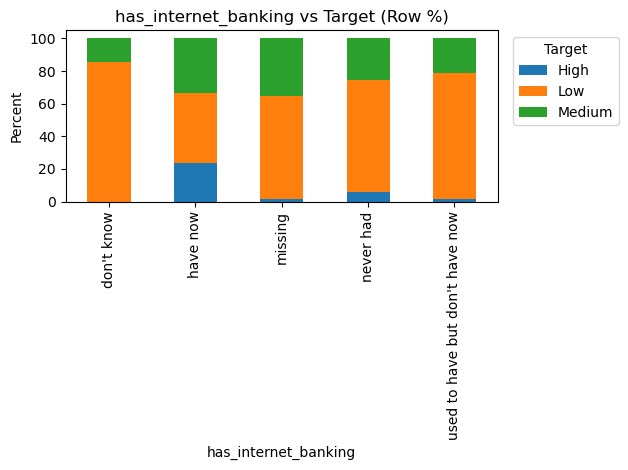

Target,High,Low,Medium
has_mobile_money,,,
don't know,0.00,83.33,16.67
have now,7.03,59.62,33.35
missing,1.31,69.57,29.12
never had,4.45,72.75,22.80
used to have but don't have now,6.29,79.72,13.99


<Figure size 640x480 with 0 Axes>

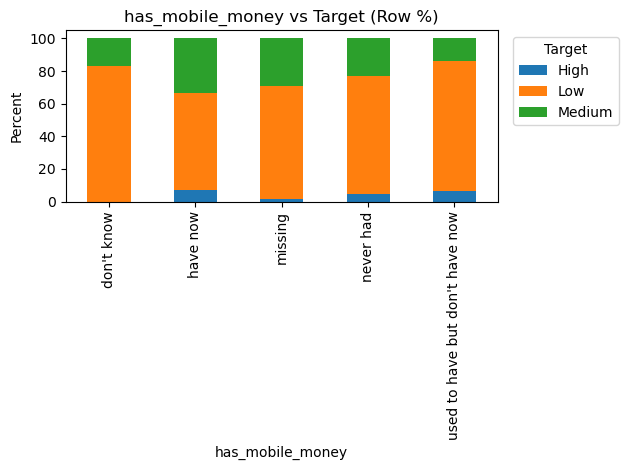

In [9]:
# Key features: Access to finance
# These columns are strong predictors for FHI.

access_cols = [
    "has_loan_account",
    "has_debit_card",
    "has_credit_card",
    "has_internet_banking",
    "has_mobile_money",
]

for c in access_cols:
    if c in train.columns:
        plot_categorical_vs_target(train, c)

Target,High,Low,Medium
has_insurance,,,
missing,0.41,60.38,39.21
no,4.87,69.14,25.99
yes,35.89,0.00,64.11


<Figure size 640x480 with 0 Axes>

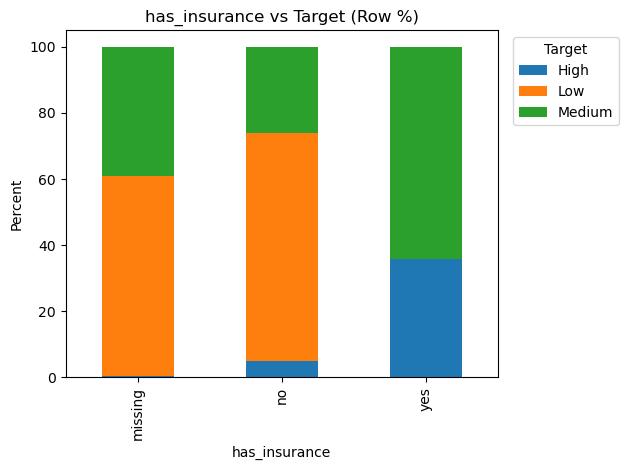

Target,High,Low,Medium
motor_vehicle_insurance,,,
don't know,0.00,88.89,11.11
have now,30.98,5.72,63.30
missing,1.87,86.01,12.12
never had,4.65,61.34,34.01
used to have but don't have now,23.40,23.40,53.19


<Figure size 640x480 with 0 Axes>

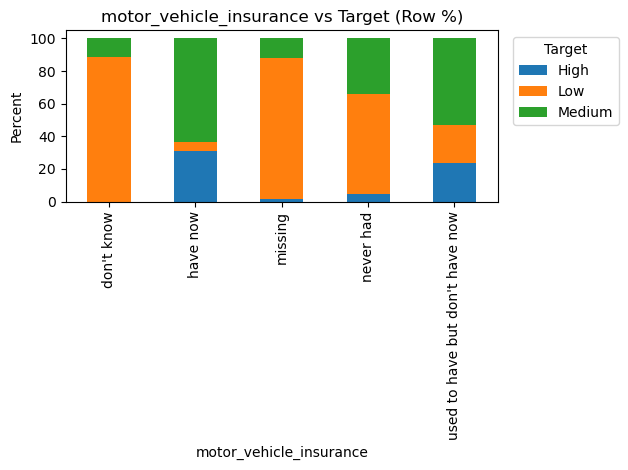

Target,High,Low,Medium
medical_insurance,,,
don't know,0.00,82.35,17.65
have now,23.51,0.00,76.49
missing,1.15,74.12,24.74
never had,6.53,64.25,29.22
used to have but don't have now,6.51,38.14,55.35


<Figure size 640x480 with 0 Axes>

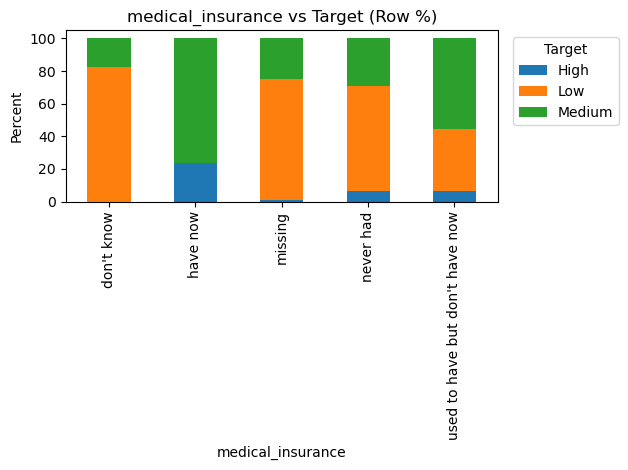

Target,High,Low,Medium
funeral_insurance,,,
don't know,7.69,88.46,3.85
have now,19.90,0.00,80.10
missing,1.15,74.12,24.74
never had,2.52,83.37,14.11
used to have but don't have now,4.97,76.80,18.23


<Figure size 640x480 with 0 Axes>

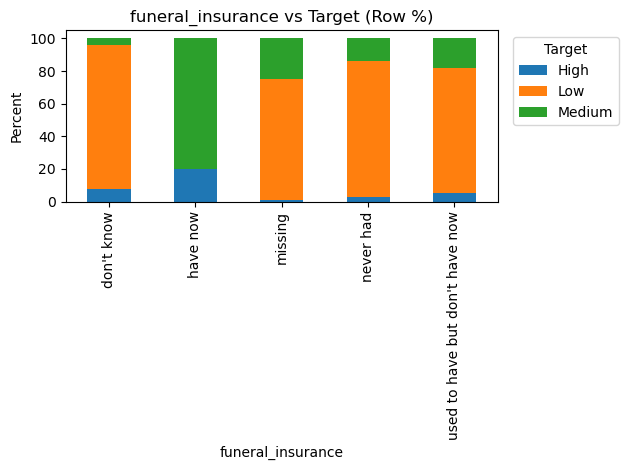

Target,High,Low,Medium
perception_insurance_important,,,
don't know,0.52,86.27,13.21
missing,0.36,60.41,39.23
no,2.80,70.17,27.03
yes,8.27,61.39,30.34


<Figure size 640x480 with 0 Axes>

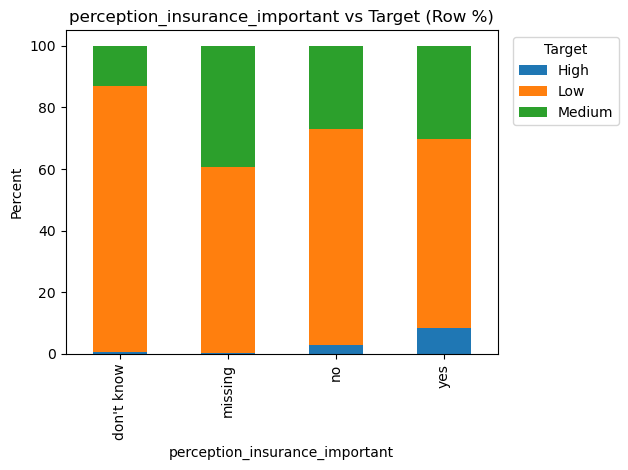

In [10]:
# Key features: Insurance

insurance_cols = [
    "has_insurance",
    "motor_vehicle_insurance",
    "medical_insurance",
    "funeral_insurance",
    "perception_insurance_important",
    "perception_insurance_cannot_afford_insurance",
]

for c in insurance_cols:
    if c in train.columns:
        plot_categorical_vs_target(train, c)

Target,High,Low,Medium
current_problem_cash_flow,,,
missing,1.56,65.30,33.14
no,6.60,70.15,23.26
yes,7.55,59.60,32.85


<Figure size 640x480 with 0 Axes>

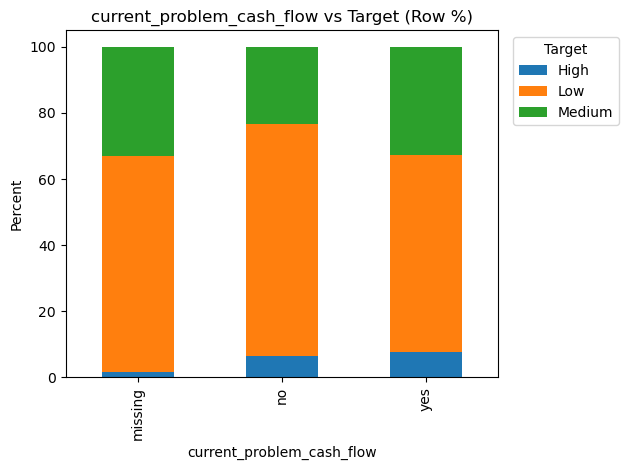

Target,High,Low,Medium
problem_sourcing_money,,,
missing,4.24,64.73,31.03
no,2.35,70.23,27.42
yes,7.36,62.34,30.30


<Figure size 640x480 with 0 Axes>

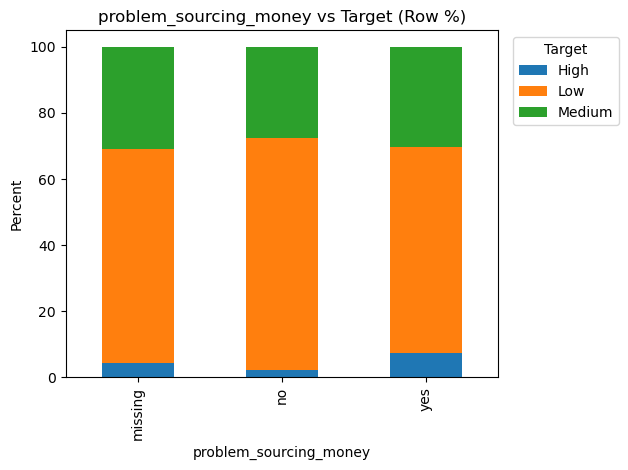

Target,High,Low,Medium
attitude_worried_shutdown,,,
don't know,5.06,67.51,27.43
missing,0.00,100.00,0.00
no,5.27,62.06,32.67
yes,4.25,70.38,25.37


<Figure size 640x480 with 0 Axes>

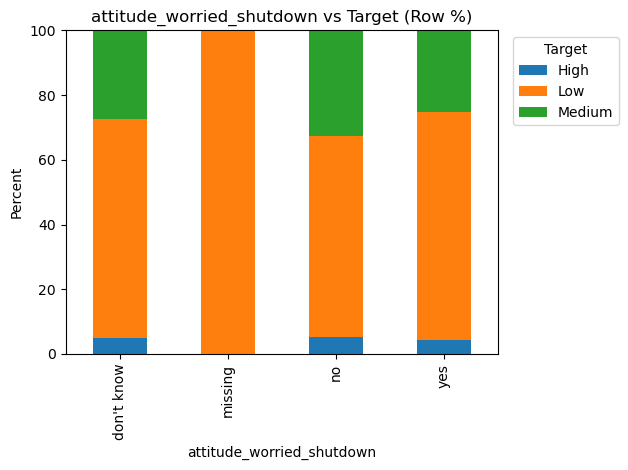

Target,High,Low,Medium
perception_insurance_doesnt_cover_losses,,,
don't know,0.99,75.90,23.11
missing,0.00,40.00,60.00
no,7.16,60.23,32.61
yes,4.76,63.79,31.45


<Figure size 640x480 with 0 Axes>

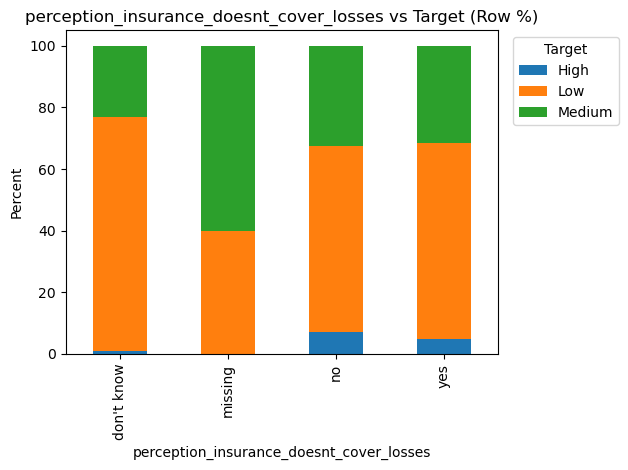

In [11]:
# Key features: Shocks / resilience

resilience_cols = [
    "current_problem_cash_flow",
    "problem_sourcing_money",
    "attitude_worried_shutdown",
    "perception_insurance_doesnt_cover_losses",
]

for c in resilience_cols:
    if c in train.columns:
        plot_categorical_vs_target(train, c)

C:\Users\otsyu\AppData\Local\Temp\ipykernel_13876\739353619.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showfliers=False)


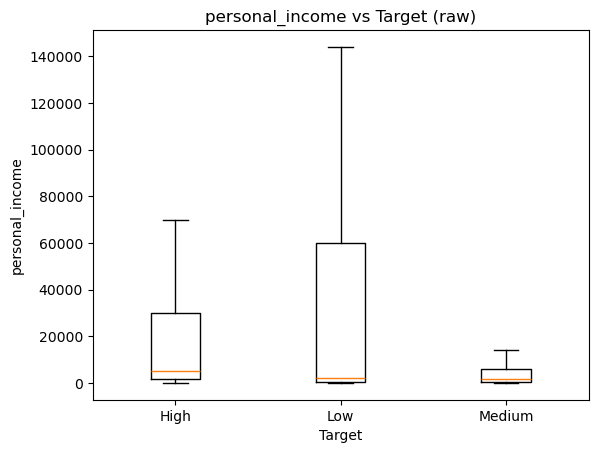

,count,mean,std,min,10%,50%,90%,max
Target,,,,,,,,
High,464.0,882802.239,4715191.067,15.0,500.0,5000.0,900000.0,60000000.0
Low,6209.0,254094.823,2546815.146,0.0,80.0,2000.0,500000.0,150000000.0
Medium,2836.0,180199.970,2045196.190,0.0,100.0,1500.0,100000.0,84000000.0


C:\Users\otsyu\AppData\Local\Temp\ipykernel_13876\739353619.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showfliers=False)


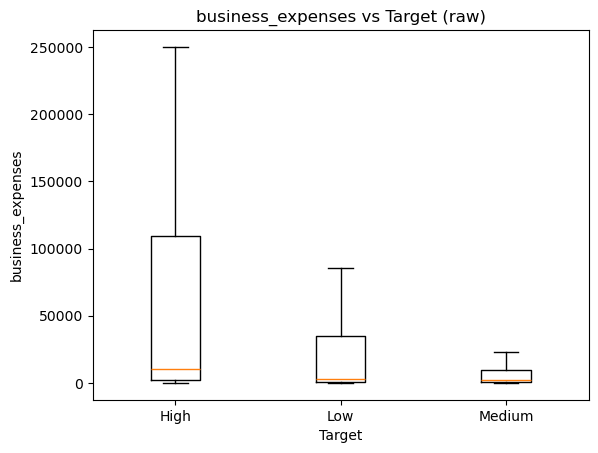

,count,mean,std,min,10%,50%,90%,max
Target,,,,,,,,
High,464.0,1062800.573,8584023.555,20.0,700.0,10100.0,847210.0,149000000.0
Low,6137.0,485568.597,6866860.618,0.0,200.0,3000.0,320000.0,500000000.0
Medium,2788.0,297952.645,3564138.259,0.0,150.0,2000.0,100000.0,150000000.0


C:\Users\otsyu\AppData\Local\Temp\ipykernel_13876\739353619.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showfliers=False)


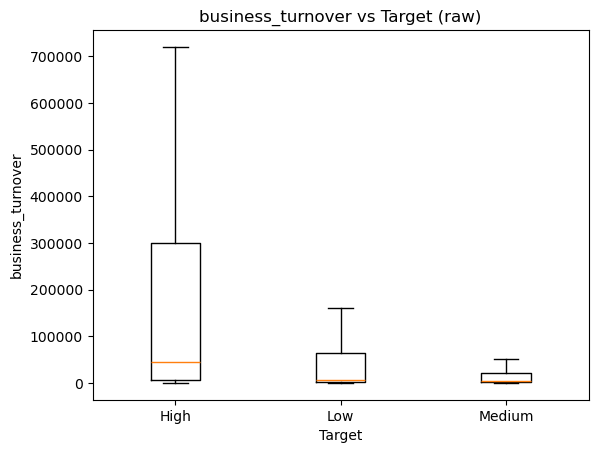

,count,mean,std,min,10%,50%,90%,max
Target,,,,,,,,
High,463.0,5598924.413,3.090331e+07,90.0,1800.0,45000.0,6480000.0,420000000.0
Low,6145.0,1253353.390,5.428415e+06,0.0,480.0,6000.0,2520000.0,120000000.0
Medium,2794.0,852437.069,5.906061e+06,20.0,400.0,4500.0,250000.0,127750000.0


C:\Users\otsyu\AppData\Local\Temp\ipykernel_13876\739353619.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showfliers=False)


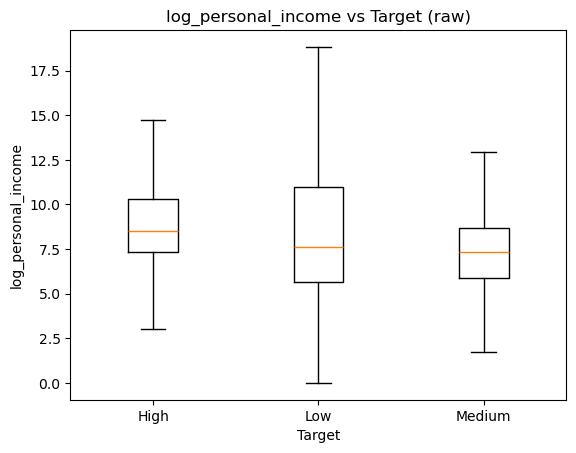

,count,mean,std,min,10%,50%,90%,max
Target,,,,,,,,
High,464.0,9.173,2.888,2.773,6.217,8.517,13.710,17.910
Low,6209.0,8.216,3.270,0.000,4.394,7.601,13.122,18.826
Medium,2836.0,7.619,2.558,0.000,4.615,7.314,11.513,18.246


C:\Users\otsyu\AppData\Local\Temp\ipykernel_13876\739353619.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showfliers=False)


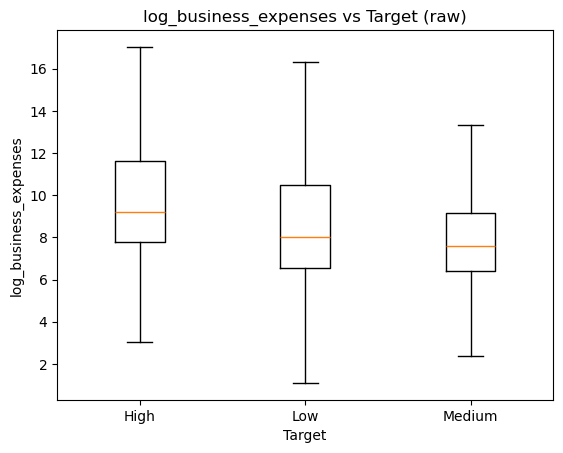

,count,mean,std,min,10%,50%,90%,max
Target,,,,,,,,
High,464.0,9.767,2.762,3.045,6.553,9.220,13.650,18.819
Low,6137.0,8.583,2.887,0.000,5.303,8.007,12.676,20.030
Medium,2788.0,8.010,2.525,0.000,5.017,7.601,11.513,18.826


C:\Users\otsyu\AppData\Local\Temp\ipykernel_13876\739353619.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showfliers=False)


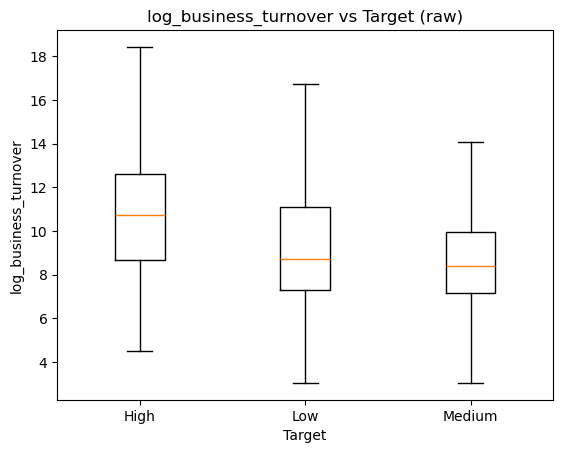

,count,mean,std,min,10%,50%,90%,max
Target,,,,,,,,
High,463.0,10.988,3.068,4.511,7.496,10.714,15.684,19.856
Low,6145.0,9.487,3.136,0.000,6.176,8.700,14.740,18.603
Medium,2794.0,8.865,2.655,3.045,5.994,8.412,12.429,18.666


In [12]:
# Key features: Business scale (numeric)

numeric_cols = [
    "personal_income",
    "business_expenses",
    "business_turnover",
    "log_personal_income",
    "log_business_expenses",
    "log_business_turnover",
]

for c in numeric_cols:
    if c in train.columns:
        plot_numeric_vs_target(train, c, use_log=False if not c.startswith("log_") else False)

C:\Users\otsyu\AppData\Local\Temp\ipykernel_13876\739353619.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showfliers=False)


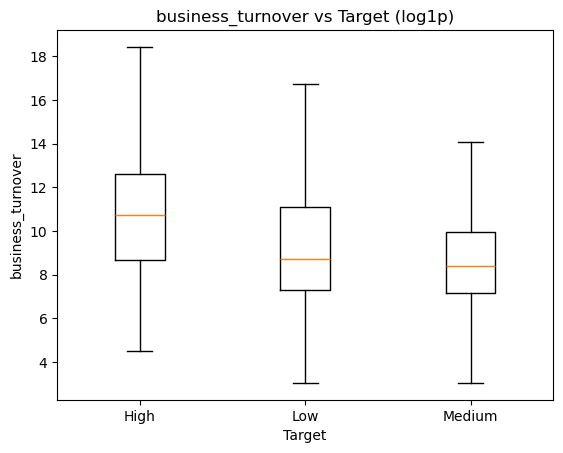

,count,mean,std,min,10%,50%,90%,max
Target,,,,,,,,
High,463.0,10.988,3.068,4.511,7.496,10.714,15.684,19.856
Low,6145.0,9.487,3.136,0.000,6.176,8.700,14.740,18.603
Medium,2794.0,8.865,2.655,3.045,5.994,8.412,12.429,18.666


C:\Users\otsyu\AppData\Local\Temp\ipykernel_13876\739353619.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showfliers=False)


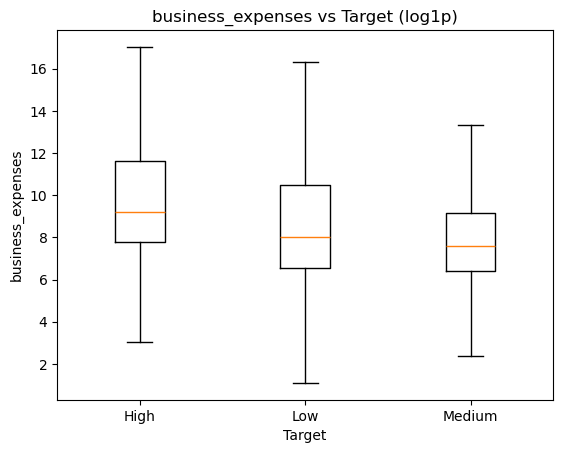

,count,mean,std,min,10%,50%,90%,max
Target,,,,,,,,
High,464.0,9.767,2.762,3.045,6.553,9.220,13.650,18.819
Low,6137.0,8.583,2.887,0.000,5.303,8.007,12.676,20.030
Medium,2788.0,8.010,2.525,0.000,5.017,7.601,11.513,18.826


C:\Users\otsyu\AppData\Local\Temp\ipykernel_13876\739353619.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showfliers=False)


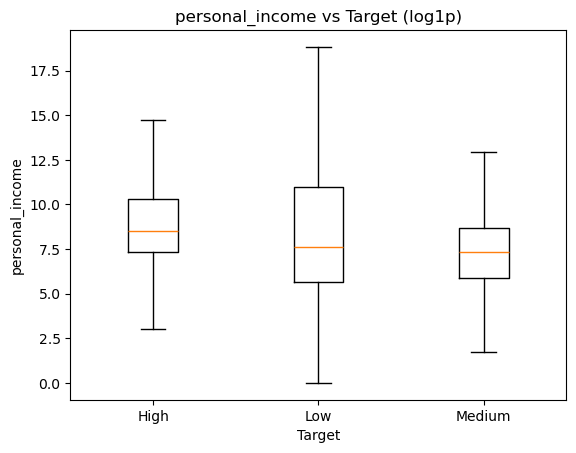

,count,mean,std,min,10%,50%,90%,max
Target,,,,,,,,
High,464.0,9.173,2.888,2.773,6.217,8.517,13.710,17.910
Low,6209.0,8.216,3.270,0.000,4.394,7.601,13.122,18.826
Medium,2836.0,7.619,2.558,0.000,4.615,7.314,11.513,18.246


In [13]:
# visualize log for  raw money columns

for c in ["business_turnover", "business_expenses", "personal_income"]:
    if c in train.columns:
        plot_numeric_vs_target(train, c, use_log=True)

C:\Users\otsyu\AppData\Local\Temp\ipykernel_13876\739353619.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showfliers=False)


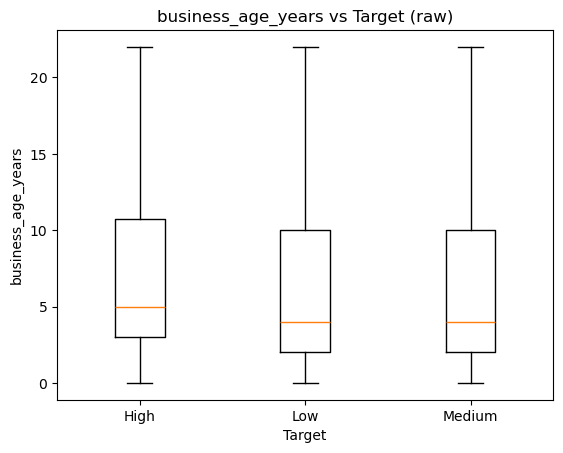

,count,mean,std,min,10%,50%,90%,max
Target,,,,,,,,
High,466.0,8.015,7.808,0.0,1.0,5.0,18.0,45.0
Low,6075.0,7.034,7.756,0.0,1.0,4.0,18.0,60.0
Medium,2825.0,6.861,7.381,0.0,1.0,4.0,16.0,53.0


C:\Users\otsyu\AppData\Local\Temp\ipykernel_13876\739353619.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showfliers=False)


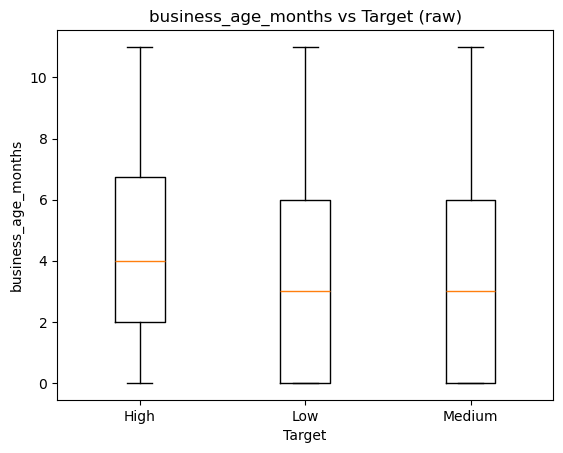

,count,mean,std,min,10%,50%,90%,max
Target,,,,,,,,
High,370.0,4.543,3.253,0.0,0.0,4.0,10.0,11.0
Low,3354.0,3.441,3.360,0.0,0.0,3.0,9.0,11.0
Medium,1783.0,3.815,3.425,0.0,0.0,3.0,9.0,11.0


C:\Users\otsyu\AppData\Local\Temp\ipykernel_13876\739353619.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showfliers=False)


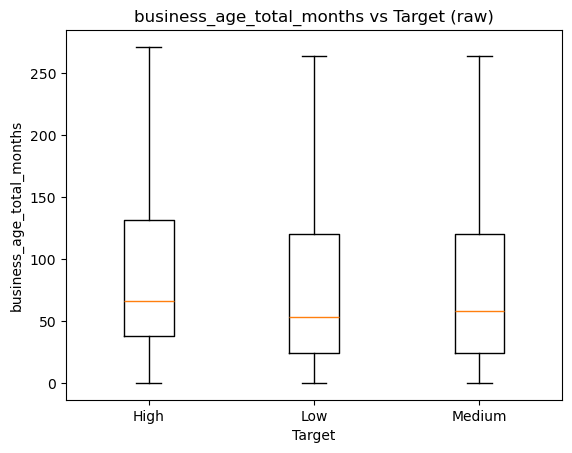

,count,mean,std,min,10%,50%,90%,max
Target,,,,,,,,
High,466.0,99.764,93.720,0.0,18.0,66.0,216.0,548.0
Low,6075.0,86.134,92.850,0.0,12.0,53.0,216.0,720.0
Medium,2825.0,84.674,88.522,0.0,12.0,58.0,192.0,636.0


In [14]:
# Business maturity

maturity_cols = ["business_age_years", "business_age_months", "business_age_total_months"]

for c in maturity_cols:
    if c in train.columns:
        plot_numeric_vs_target(train, c, use_log=False)

## Multivariate exploration

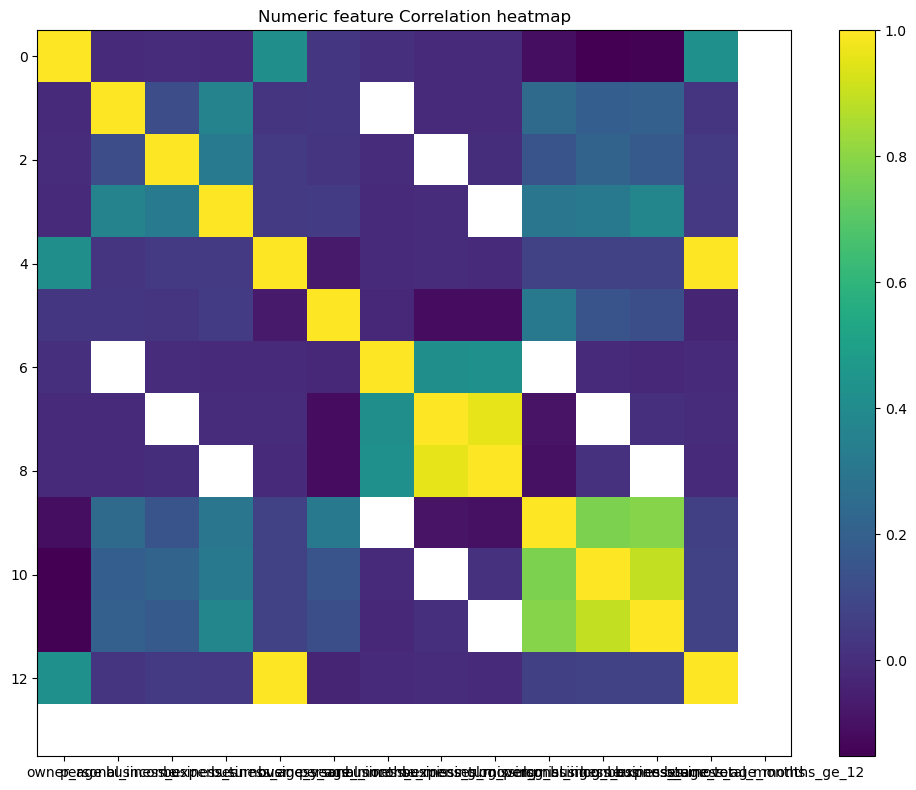

,owner_age,personal_income,business_expenses,business_turnover,business_age_years,business_age_months,personal_income_missing,business_expenses_missing,business_turnover_missing,log_personal_income,log_business_expenses,log_business_turnover,business_age_total_months,business_age_months_ge_12
owner_age,1.000,-0.015,-0.004,-0.013,0.422,0.032,0.002,-0.013,-0.013,-0.110,-0.152,-0.145,0.425,NaN
personal_income,-0.015,1.000,0.118,0.361,0.022,0.030,NaN,-0.012,-0.013,0.248,0.190,0.202,0.020,NaN
business_expenses,-0.004,0.118,1.000,0.317,0.046,0.026,-0.005,NaN,-0.001,0.145,0.214,0.173,0.045,NaN
business_turnover,-0.013,0.361,0.317,1.000,0.043,0.052,-0.010,-0.005,NaN,0.302,0.312,0.378,0.040,NaN
business_age_years,0.422,0.022,0.046,0.043,1.000,-0.069,-0.014,-0.007,-0.010,0.073,0.073,0.077,0.999,NaN
business_age_months,0.032,0.030,0.026,0.052,-0.069,1.000,-0.025,-0.116,-0.113,0.313,0.148,0.125,-0.032,NaN
personal_income_missing,0.002,NaN,-0.005,-0.010,-0.014,-0.025,1.000,0.421,0.428,NaN,-0.009,-0.018,-0.013,NaN
business_expenses_missing,-0.013,-0.012,NaN,-0.005,-0.007,-0.116,0.421,1.000,0.957,-0.091,NaN,0.008,-0.007,NaN
business_turnover_missing,-0.013,-0.013,-0.001,NaN,-0.010,-0.113,0.428,0.957,1.000,-0.101,0.012,NaN,-0.010,NaN
log_personal_income,-0.110,0.248,0.145,0.302,0.073,0.313,NaN,-0.091,-0.101,1.000,0.773,0.791,0.066,NaN


In [16]:
# Numeric correlation heatmap (matplotlib)

num_df = train.select_dtypes(include=[np.number]).copy()
corr = num_df.corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr, aspect="auto")
plt.title("Numeric feature Correlation heatmap")
plt.xticks(range(len(corr.columns)), corr.columns)
plt.colorbar()
plt.tight_layout()
plt.show()

corr.round(3)

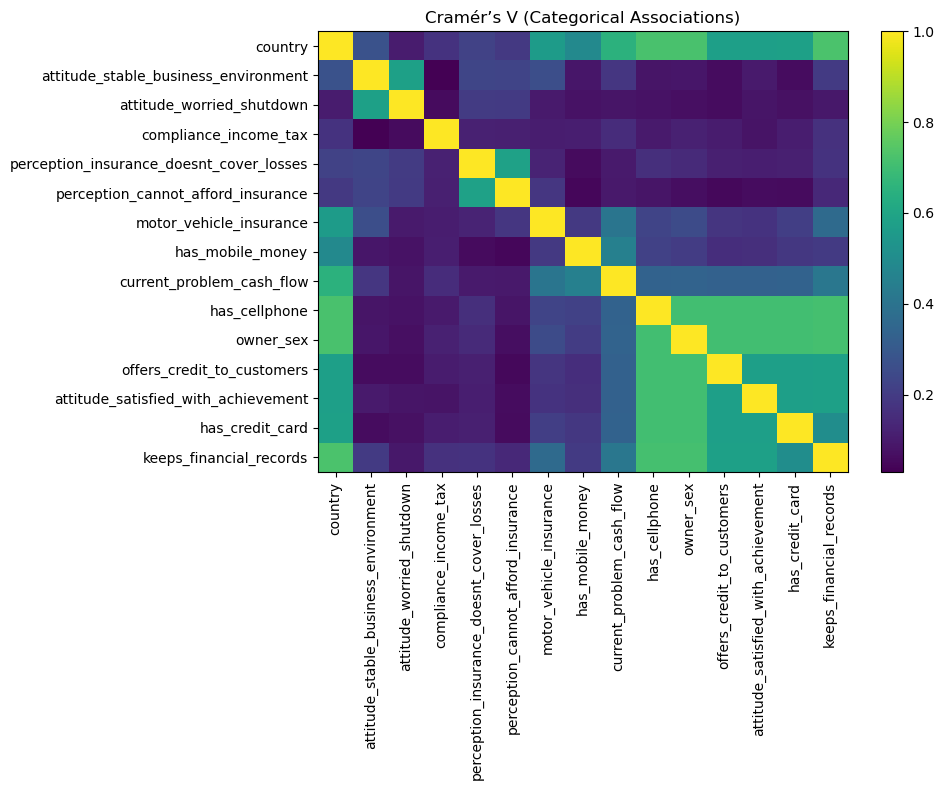

,country,attitude_stable_business_environment,attitude_worried_shutdown,compliance_income_tax,perception_insurance_doesnt_cover_losses,perception_cannot_afford_insurance,motor_vehicle_insurance,has_mobile_money,current_problem_cash_flow,has_cellphone,owner_sex,offers_credit_to_customers,attitude_satisfied_with_achievement,has_credit_card,keeps_financial_records
country,1.000,0.276,0.104,0.170,0.221,0.190,0.560,0.487,0.655,0.723,0.720,0.579,0.578,0.581,0.725
attitude_stable_business_environment,0.276,1.000,0.582,0.030,0.232,0.229,0.262,0.087,0.182,0.085,0.088,0.062,0.100,0.062,0.196
attitude_worried_shutdown,0.104,0.582,1.000,0.056,0.197,0.194,0.098,0.076,0.086,0.078,0.068,0.061,0.084,0.073,0.091
compliance_income_tax,0.170,0.030,0.056,1.000,0.118,0.116,0.109,0.110,0.151,0.098,0.120,0.104,0.079,0.109,0.167
perception_insurance_doesnt_cover_losses,0.221,0.232,0.197,0.118,1.000,0.583,0.126,0.059,0.101,0.159,0.146,0.116,0.112,0.116,0.171
perception_cannot_afford_insurance,0.190,0.229,0.194,0.116,0.583,1.000,0.181,0.045,0.094,0.083,0.065,0.049,0.062,0.057,0.142
motor_vehicle_insurance,0.560,0.262,0.098,0.109,0.126,0.181,1.000,0.190,0.406,0.229,0.250,0.180,0.172,0.210,0.363
has_mobile_money,0.487,0.087,0.076,0.110,0.059,0.045,0.190,1.000,0.451,0.218,0.202,0.157,0.162,0.187,0.193
current_problem_cash_flow,0.655,0.182,0.086,0.151,0.101,0.094,0.406,0.451,1.000,0.333,0.339,0.331,0.331,0.336,0.416
has_cellphone,0.723,0.085,0.078,0.098,0.159,0.083,0.229,0.218,0.333,1.000,0.707,0.707,0.707,0.708,0.714


In [17]:
# Cramér’s V for categorical associationss

from scipy.stats import chi2_contingency

def cramers_v(x, y):
    """Compute Cramér's V statistic for categorical-categorical association."""
    confusion = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion)[0]
    n = confusion.sum().sum()
    r, k = confusion.shape
    return np.sqrt((chi2 / n) / (min(k-1, r-1) + 1e-12))

cat_cols = [c for c in train.columns if train[c].dtype == "str" and c not in [TARGET, ID]]

# pick a subset to avoid huge compute
subset = cat_cols[:15]  # adjust as needed

cv_mat = pd.DataFrame(index=subset, columns=subset, dtype=float)

for i in range(len(subset)):
    for j in range(len(subset)):
        if i == j:
            cv_mat.iloc[i, j] = 1.0
        else:
            cv_mat.iloc[i, j] = cramers_v(train[subset[i]].fillna("missing"),
                                          train[subset[j]].fillna("missing"))

plt.figure(figsize=(10, 8))
plt.imshow(cv_mat.values, aspect="auto")
plt.title("Cramér’s V (Categorical Associations)")
plt.xticks(range(len(subset)), subset, rotation=90)
plt.yticks(range(len(subset)), subset)
plt.colorbar()
plt.tight_layout()
plt.show()

cv_mat.round(3)

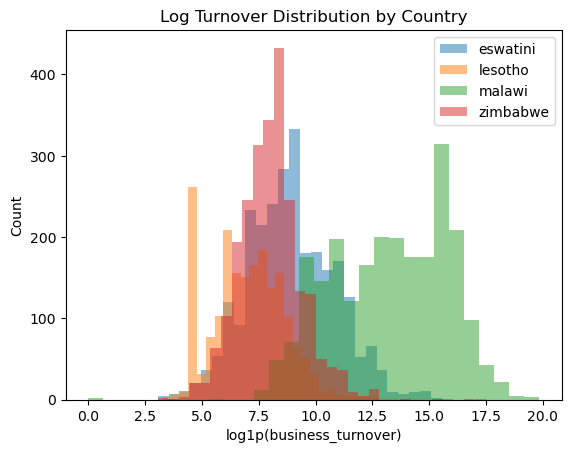

In [18]:
# Country interactions: turnover by country

if "country" in train.columns and "business_turnover" in train.columns:
    plt.figure()
    for country in sorted(train["country"].dropna().unique()):
        vals = train.loc[train["country"] == country, "business_turnover"].dropna()
        vals = np.log1p(vals.clip(lower=0))
        plt.hist(vals, bins=30, alpha=0.5, label=country)
    plt.title("Log Turnover Distribution by Country")
    plt.xlabel("log1p(business_turnover)")
    plt.ylabel("Count")
    plt.legend()
    plt.show()

## Data drift check (Train vs Test)

In [19]:
# Category frequency drift. 
# Identify categories that appear only in test.

def category_drift_report(train_df, test_df, col, top_n=15):
    tr = train_df[col].fillna("missing").astype(str)
    te = test_df[col].fillna("missing").astype(str)

    tr_vc = (tr.value_counts(normalize=True) * 100).rename("train_pct")
    te_vc = (te.value_counts(normalize=True) * 100).rename("test_pct")

    combined = pd.concat([tr_vc, te_vc], axis=1).fillna(0)
    combined["abs_diff"] = (combined["train_pct"] - combined["test_pct"]).abs()
    combined = combined.sort_values("abs_diff", ascending=False)

    only_test = sorted(list(set(te.unique()) - set(tr.unique())))
    only_train = sorted(list(set(tr.unique()) - set(te.unique())))

    return combined.head(top_n), only_train[:20], only_test[:20]

cat_cols = [c for c in train.columns if train[c].dtype == "str" and c not in [TARGET, ID]]

for col in ["country", "owner_sex", "has_loan_account", "has_mobile_money"]:
    if col in cat_cols:
        rep, only_train, only_test = category_drift_report(train, test, col)
        print(f"\n=== Drift report: {col} ===")
        display(rep)
        print("Only in train (sample):", only_train)
        print("Only in test  (sample):", only_test)
        


=== Drift report: country ===


,train_pct,test_pct,abs_diff
country,,,
eswatini,27.802038,27.817048,0.015010
zimbabwe,27.157413,27.151767,0.005646
malawi,24.828447,24.823285,0.005162
lesotho,20.212102,20.207900,0.004202


Only in train (sample): []
Only in test  (sample): []

=== Drift report: owner_sex ===


,train_pct,test_pct,abs_diff
owner_sex,,,
male,35.048867,36.590437,1.541570
female,44.739031,43.201663,1.537368
missing,20.212102,20.207900,0.004202


Only in train (sample): []
Only in test  (sample): []

=== Drift report: has_loan_account ===


,train_pct,test_pct,abs_diff
has_loan_account,,,
never had,46.797671,48.108108,1.310437
used to have but don't have now,6.851736,5.945946,0.905790
missing,41.578291,41.247401,0.330889
don't know,0.239135,0.166320,0.072815
have now,4.533167,4.532225,0.000942


Only in train (sample): []
Only in test  (sample): []

=== Drift report: has_mobile_money ===


,train_pct,test_pct,abs_diff
has_mobile_money,,,
have now,50.696611,49.106029,1.590581
missing,28.602620,29.521830,0.919209
never had,19.151591,19.667360,0.515769
used to have but don't have now,1.486796,1.663202,0.176406
don't know,0.062383,0.041580,0.020803


Only in train (sample): []
Only in test  (sample): []


In [20]:
# Numeric drift using PSI (Population Stability Index)

def psi(expected, actual, buckets=10):
    """
    Compute Population Stability Index (PSI) between two numeric distributions.
    expected = train, actual = test.
    """
    expected = pd.Series(expected).dropna()
    actual = pd.Series(actual).dropna()

    # Define bins using expected quantiles
    breakpoints = np.percentile(expected, np.linspace(0, 100, buckets + 1))
    breakpoints = np.unique(breakpoints)
    if len(breakpoints) < 3:
        return np.nan

    exp_counts = np.histogram(expected, bins=breakpoints)[0] / len(expected)
    act_counts = np.histogram(actual, bins=breakpoints)[0] / len(actual)

    # Avoid division by zero
    exp_counts = np.where(exp_counts == 0, 1e-6, exp_counts)
    act_counts = np.where(act_counts == 0, 1e-6, act_counts)

    return np.sum((act_counts - exp_counts) * np.log(act_counts / exp_counts))

psi_results = []
for col in ["personal_income", "business_expenses", "business_turnover",
            "log_personal_income", "log_business_expenses", "log_business_turnover"]:
    if col in train.columns and col in test.columns:
        psi_val = psi(train[col], test[col], buckets=10)
        psi_results.append((col, psi_val))

psi_df = pd.DataFrame(psi_results, columns=["column", "PSI"]).sort_values("PSI", ascending=False)
display(psi_df)

,column,PSI
0,personal_income,0.005956
3,log_personal_income,0.005956
5,log_business_turnover,0.004247
2,business_turnover,0.004247
1,business_expenses,0.004128
4,log_business_expenses,0.004128


### Hypothesis Notes

In [21]:
hypotheses = [
    "H1: SMEs with more formal financial access (loan account/debit/credit/internet banking) are more likely to be Medium/High FHI.",
    "H2: SMEs reporting cash flow problems and sourcing money issues are more likely to be Low FHI.",
    "H3: Insurance coverage (has insurance + medical/funeral/motor) correlates positively with High FHI.",
    "H4: Country strongly affects feature distributions (especially turnover/expenses), suggesting possible domain shift risk.",
    "H5: Missingness in certain finance variables may be informative (survey skip logic), therefore missing flags will improve performance."
]

for h in hypotheses:
    print("-", h)

- H1: SMEs with more formal financial access (loan account/debit/credit/internet banking) are more likely to be Medium/High FHI.
- H2: SMEs reporting cash flow problems and sourcing money issues are more likely to be Low FHI.
- H3: Insurance coverage (has insurance + medical/funeral/motor) correlates positively with High FHI.
- H4: Country strongly affects feature distributions (especially turnover/expenses), suggesting possible domain shift risk.
- H5: Missingness in certain finance variables may be informative (survey skip logic), therefore missing flags will improve performance.
